## ¿Por qué el modelo falla con nuestras grabaciones?

El modelo alcanza un accuracy del 97% y AUC 0.98 sobre el conjunto de evaluación oficial, pero clasifica incorrectamente la mayoría de nuestros audios reales.

Esta diferencia se debe a que el modelo aprendió a reconocer voz bonafide tal como suena en el dataset, que fue grabado en condiciones controladas (audio limpio, sin ruido de fondo, micrófono profesional, formato FLAC sin compresión).

Nuestras grabaciones presentan características acústicas distintas:

- Grabadas con micrófonos de teléfono móvil
- Compresión AAC (formato m4a) con artefactos de códec
- Ruido ambiental y reverberación de sala
- Diferente respuesta en frecuencia del micrófono

A continuación comparamos visualmente los espectrogramas de ambas fuentes para identificar diferencias entre nuestros audios y los audios del dataset.

Usaremos espectrogramas y no formas de onda porque el modelo opera exclusivamente en el dominio de la frecuencia: recibe espectrogramas STFT como entrada y nunca procesa la señal de audio en el tiempo. Por lo tanto, analizar similitudes en el dominio del tiempo es irrelevante para explicar por qué el modelo falla.


### Espectrogramas:

Compararemos el espectrograma de nuestras grabaciones contra la media de los espectrogramas spoof y bonafide del dataset, para verificar si visualmente nuestros audios se acercan más a alguna de las dos clases.

Total: 22 | Bonafide: 7 | Spoof: 15
Media spoof: 100 audios | Media bonafide: 100 audios


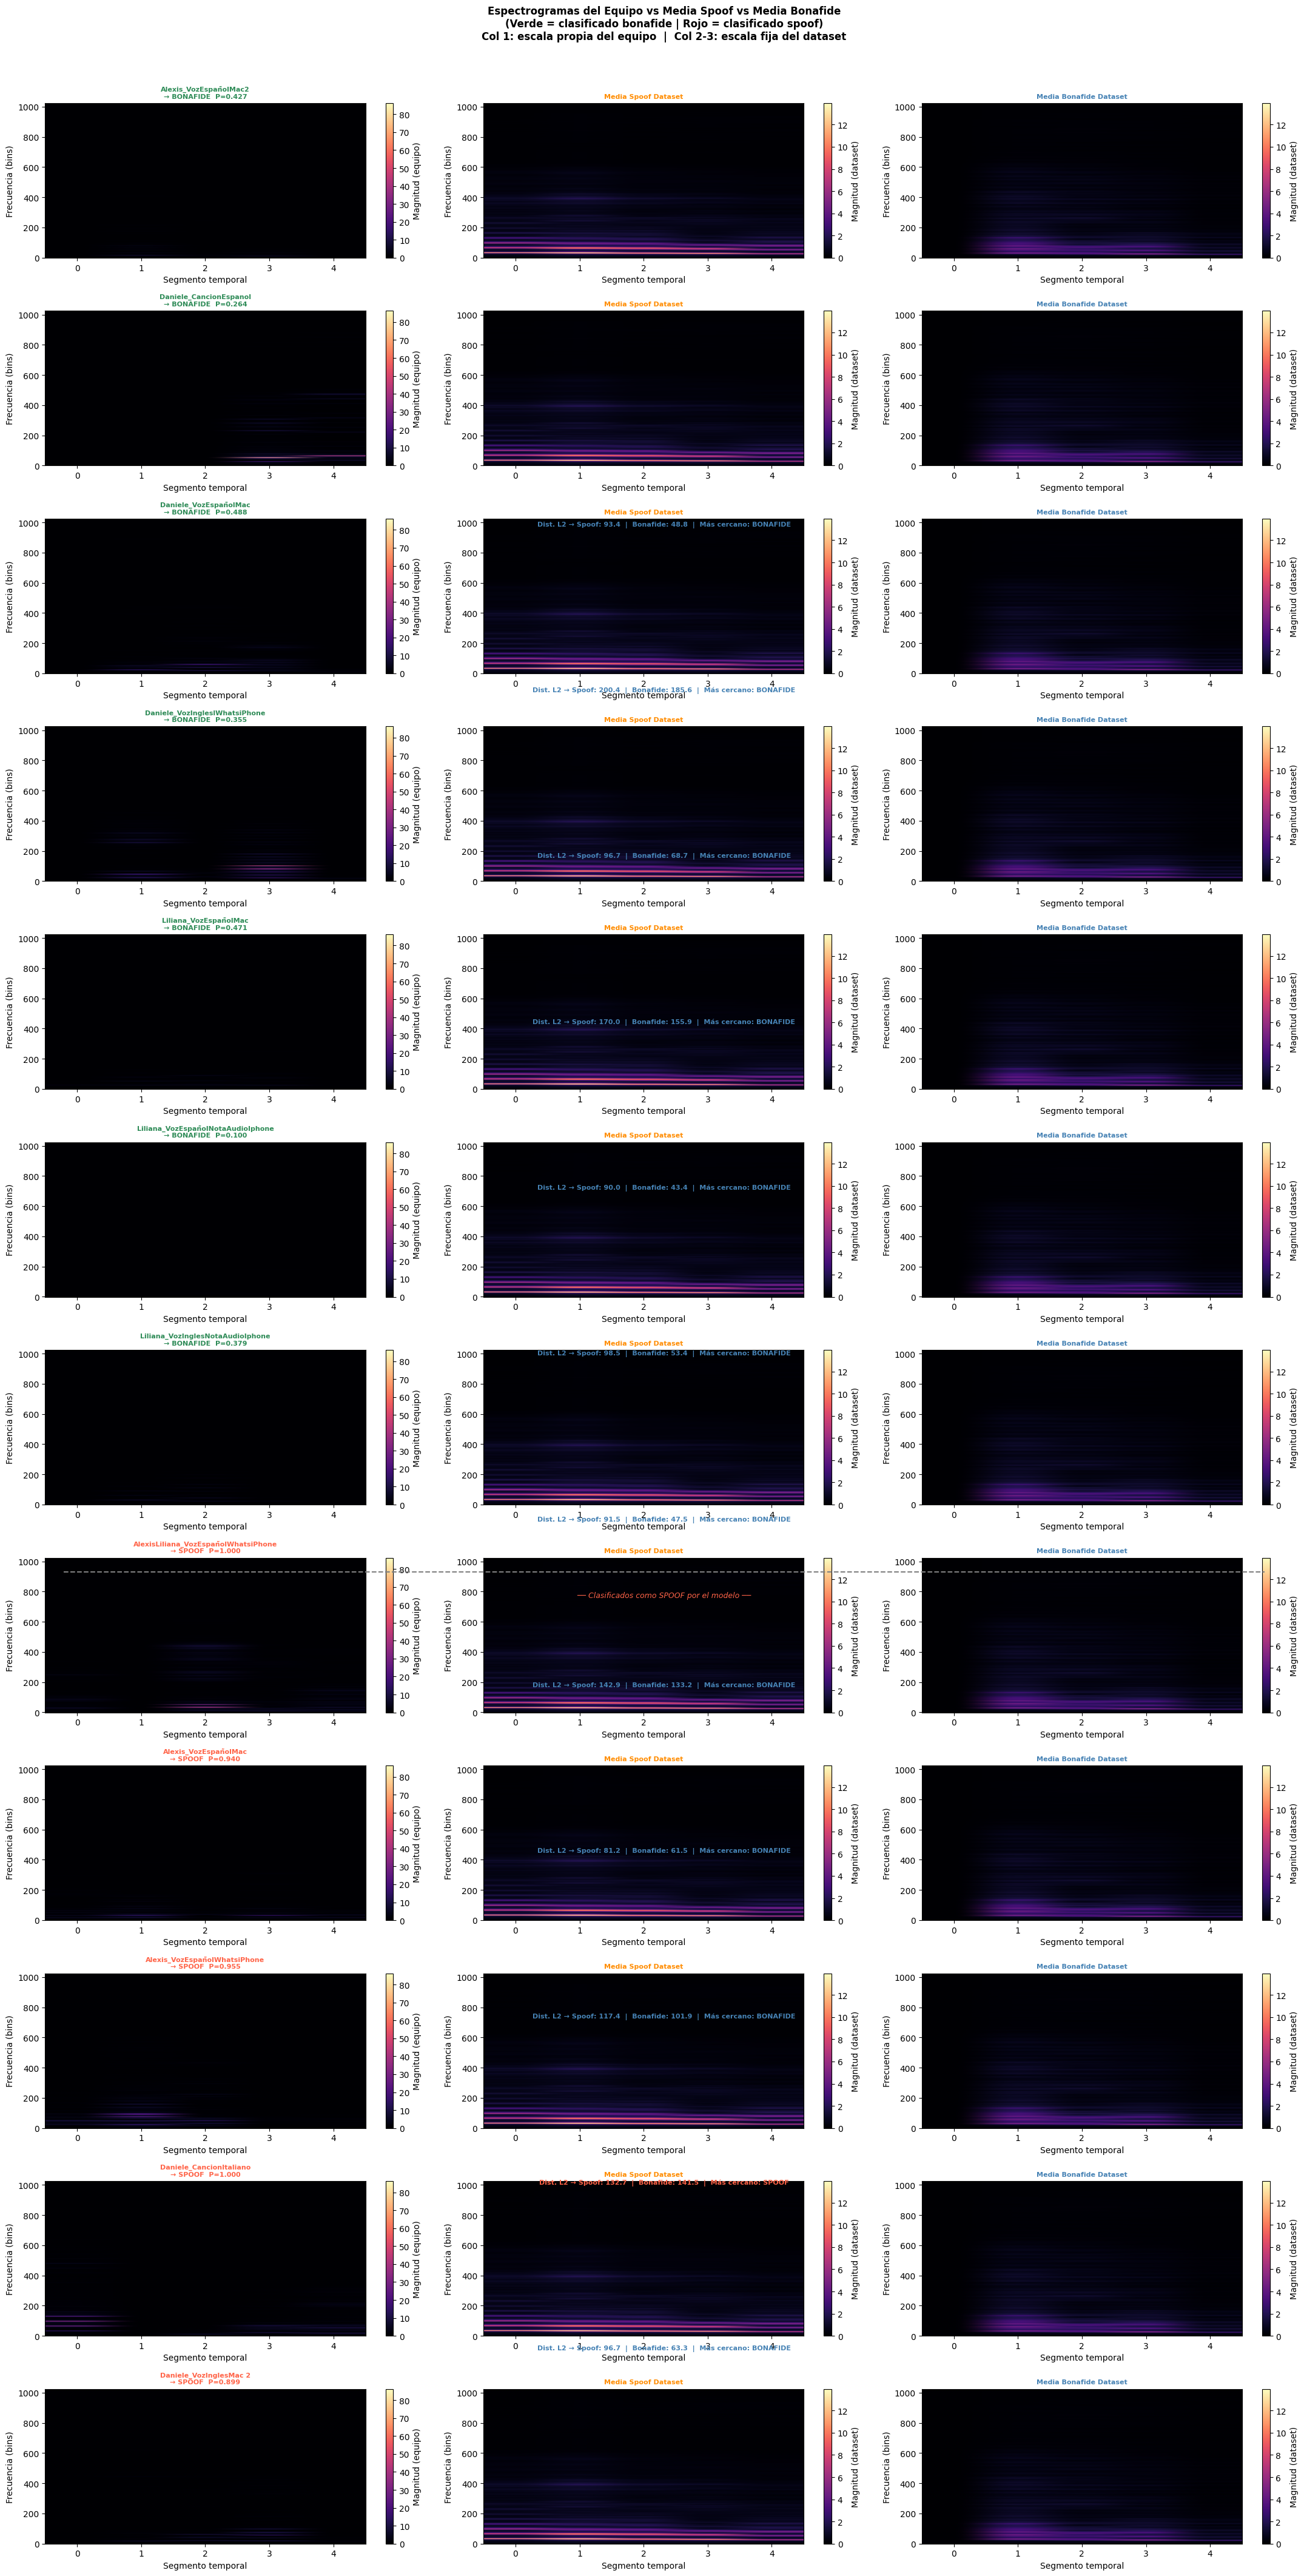


── Similitud numérica (distancia L2 al espectrograma medio) ──
Audio                                           Dist. vs Spoof  Dist. vs Bonafide  Más cercano
───────────────────────────────────────────────────────────────────────────────────────────────
AlexisLiliana_VozEspañolWhatsiPhone                     142.9              133.2  ← BONAFIDE
Alexis_VozEspañolMac2                                    93.4               48.8  ← BONAFIDE
Alexis_VozEspañolMac                                     81.2               61.5  ← BONAFIDE
Alexis_VozEspañolWhatsiPhone                            117.4              101.9  ← BONAFIDE
Daniele_CancionEspanol                                   200.4              185.6  ← BONAFIDE
Daniele_CancionItaliano                                  132.7              141.5  ← SPOOF
Daniele_VozEspañolMac                                    96.7               68.7  ← BONAFIDE
Daniele_VozInglesMac 2                                    96.7               63.3  ← BONAF

In [15]:
import os
import glob
import numpy as np
import librosa
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

# ── Parámetros ────────────────────────────────────────────────────────────────
TARGET_SR     = 16000
FRAME_LEN     = 2048
N_FRAMES      = 5
RUTA_MODELO   = '../Metricas/modelo2_1_balanceado.keras'
RUTA_VOCES    = '../test_voces/'
RUTA_PROTO    = '../data/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt'
RUTA_AUDIO    = '../data/LA/ASVspoof2019_LA_train/flac/'
N_MEDIA       = 100

def calcular_segmentos_uniformes(total_samples):
    segment_size = total_samples // N_FRAMES
    indices = []
    for i in range(N_FRAMES):
        center = (i * segment_size) + (segment_size // 2)
        start  = center - (FRAME_LEN // 2)
        end    = start + FRAME_LEN
        if start < 0:           start, end = 0, FRAME_LEN
        if end > total_samples: start, end = total_samples - FRAME_LEN, total_samples
        indices.append((start, end))
    return indices

def audio_a_espectrograma(audio):
    frames = calcular_segmentos_uniformes(len(audio))
    features = []
    for start, end in frames:
        stft = librosa.stft(audio[start:end], n_fft=FRAME_LEN, hop_length=FRAME_LEN + 1)
        features.append(np.abs(stft))
    return np.array(features).squeeze()   # (5, 1025)

def audio_a_tensor(file_path):
    audio, _ = librosa.load(file_path, sr=TARGET_SR, mono=True)
    tensor = audio_a_espectrograma(audio)
    return audio, np.expand_dims(tensor, axis=0)

# ── 1. Predecir clase de cada grabación del equipo ────────────────────────────
modelo   = tf.keras.models.load_model(RUTA_MODELO)
archivos = sorted(glob.glob(os.path.join(RUTA_VOCES, '*_16k.wav')))

resultados = []
for ruta in archivos:
    try:
        audio, tensor = audio_a_tensor(ruta)
        prob  = modelo.predict(tensor, verbose=0)[0][0]
        clase = 'spoof' if prob > 0.5 else 'bonafide'
        resultados.append({'nombre': os.path.basename(ruta).replace('_16k.wav', ''),
                           'ruta':   ruta,
                           'audio':  audio,
                           'spec':   audio_a_espectrograma(audio),
                           'prob':   prob,
                           'clase':  clase})
    except Exception as e:
        print(f"Error en {ruta}: {e}")

df = pd.DataFrame(resultados)
clasificados_spoof    = df[df['clase'] == 'spoof']
clasificados_bonafide = df[df['clase'] == 'bonafide']
print(f"Total: {len(df)} | Bonafide: {len(clasificados_bonafide)} | Spoof: {len(clasificados_spoof)}")

# ── 2. Espectrograma medio spoof ──────────────────────────────────────────────
df_proto = pd.read_csv(RUTA_PROTO, sep=' ', header=None,
                       names=['speaker', 'file_name', '_', 'attack', 'label'])
archivos_spoof = df_proto[df_proto['label'] == 'spoof']['file_name'].tolist()
specs_spoof = []
for fname in archivos_spoof[:N_MEDIA]:
    try:
        audio, _ = librosa.load(os.path.join(RUTA_AUDIO, f"{fname}.flac"), sr=TARGET_SR, mono=True)
        specs_spoof.append(audio_a_espectrograma(audio))
    except:
        continue
media_spoof = np.mean(specs_spoof, axis=0)

# ── 3. Espectrograma medio bonafide ───────────────────────────────────────────
archivos_bon = df_proto[df_proto['label'] == 'bonafide']['file_name'].tolist()
specs_bon = []
for fname in archivos_bon[:N_MEDIA]:
    try:
        audio, _ = librosa.load(os.path.join(RUTA_AUDIO, f"{fname}.flac"), sr=TARGET_SR, mono=True)
        specs_bon.append(audio_a_espectrograma(audio))
    except:
        continue
media_bon = np.mean(specs_bon, axis=0)
print(f"Media spoof: {len(specs_spoof)} audios | Media bonafide: {len(specs_bon)} audios")

# ── 4. Gráfico ────────────────────────────────────────────────────────────────
audios_mostrar = pd.concat([
    clasificados_bonafide.assign(grupo='BONAFIDE'),
    clasificados_spoof.head(5).assign(grupo='SPOOF')
], ignore_index=True)

# Dos escalas separadas:
# - vmax_team: escala propia de las grabaciones del equipo (columna 1)
# - vmax_means: escala propia de las medias del dataset (columnas 2 y 3)
#   → garantiza que las medias se vean iguales en TODAS las filas
vmax_team  = max(row['spec'].max() for _, row in audios_mostrar.iterrows())
vmax_means = max(media_spoof.max(), media_bon.max())

n_filas = len(audios_mostrar)
fig, axes = plt.subplots(n_filas, 3, figsize=(22, n_filas * 3.5))
if n_filas == 1:
    axes = [axes]

fig.suptitle('Espectrogramas del Equipo vs Media Spoof vs Media Bonafide\n'
             '(Verde = clasificado bonafide | Rojo = clasificado spoof)\n'
             'Col 1: escala propia del equipo  |  Col 2-3: escala fija del dataset',
             fontsize=12, fontweight='bold', y=1.01)

for i, (_, row) in enumerate(audios_mostrar.iterrows()):
    spec_eq   = row['spec']
    es_spoof  = row['grupo'] == 'SPOOF'
    color_tit = 'tomato' if es_spoof else 'seagreen'
    etiqueta  = f"→ SPOOF  P={row['prob']:.3f}" if es_spoof else f"→ BONAFIDE  P={row['prob']:.3f}"

    ax1 = axes[i][0]
    im1 = ax1.imshow(spec_eq.T, aspect='auto', origin='lower',
                     cmap='magma', vmin=0, vmax=vmax_team)
    ax1.set_title(f'{row["nombre"]}\n{etiqueta}', fontsize=8, fontweight='bold', color=color_tit)
    ax1.set_ylabel('Frecuencia (bins)')
    ax1.set_xlabel('Segmento temporal')
    plt.colorbar(im1, ax=ax1, label='Magnitud (equipo)')

    ax2 = axes[i][1]
    im2 = ax2.imshow(media_spoof.T, aspect='auto', origin='lower',
                     cmap='magma', vmin=0, vmax=vmax_means)
    ax2.set_title('Media Spoof Dataset', fontsize=8, fontweight='bold', color='darkorange')
    ax2.set_ylabel('Frecuencia (bins)')
    ax2.set_xlabel('Segmento temporal')
    plt.colorbar(im2, ax=ax2, label='Magnitud (dataset)')

    ax3 = axes[i][2]
    im3 = ax3.imshow(media_bon.T, aspect='auto', origin='lower',
                     cmap='magma', vmin=0, vmax=vmax_means)
    ax3.set_title('Media Bonafide Dataset', fontsize=8, fontweight='bold', color='steelblue')
    ax3.set_ylabel('Frecuencia (bins)')
    ax3.set_xlabel('Segmento temporal')
    plt.colorbar(im3, ax=ax3, label='Magnitud (dataset)')

    dist_spo = np.linalg.norm(spec_eq - media_spoof)
    dist_bon = np.linalg.norm(spec_eq - media_bon)
    mas_cerca = "SPOOF" if dist_spo < dist_bon else "BONAFIDE"
    color_cerca = 'tomato' if mas_cerca == 'SPOOF' else 'steelblue'
    fig.text(0.5, axes[i][0].get_position().y0 - 0.02,
             f'Dist. L2 → Spoof: {dist_spo:.1f}  |  Bonafide: {dist_bon:.1f}  |  Más cercano: {mas_cerca}',
             ha='center', fontsize=8, color=color_cerca, fontweight='bold')

# Línea separadora entre sección bonafide y sección spoof
if len(clasificados_bonafide) > 0 and len(clasificados_spoof) > 0:
    sep_y = axes[len(clasificados_bonafide) - 1][0].get_position().y0 - 0.04
    fig.add_artist(plt.Line2D([0.05, 0.95], [sep_y, sep_y], transform=fig.transFigure,
                               color='gray', linewidth=1.5, linestyle='--'))
    fig.text(0.5, sep_y - 0.01, '── Clasificados como SPOOF por el modelo ──',
             ha='center', fontsize=9, color='tomato', style='italic')

plt.tight_layout()
plt.show()

# ── 5. Tabla de distancias L2 ─────────────────────────────────────────────────
print("\n── Similitud numérica (distancia L2 al espectrograma medio) ──")
print(f"{'Audio':<45} {'Dist. vs Spoof':>16} {'Dist. vs Bonafide':>18} {'Más cercano':>12}")
print("─" * 95)
for _, row in df.iterrows():
    ds = np.linalg.norm(row['spec'] - media_spoof)
    db = np.linalg.norm(row['spec'] - media_bon)
    mc = "← SPOOF" if ds < db else "← BONAFIDE"
    print(f"{row['nombre']:<45} {ds:>16.1f} {db:>18.1f}  {mc}")

Los espectrogramas globales muestran que visualmente nuestras grabaciones se parecen más al bonafide, pero el modelo las clasifica como spoof. Así que no podemos explicar el motivo con los espectrogramas globales.

Aunque el modelo no opera en el dominio del tiempo, vamos a analizar externamente si sus predicciones se correlacionan con métricas de amplitud. Si existe correlación, indicaría que el modelo aprendió un sesgo del dataset, no porque use métricas de dominio de tiempo como RMS directamente, sino porque el RMS es un síntoma de las mismas condiciones de grabación que el modelo aprendió a distinguir.

/var/folders/hg/hykq20jn2js2_z7rtp_yc7980000gn/T/ipykernel_41950/2829392378.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(data_box, labels=labels_box, patch_artist=True)


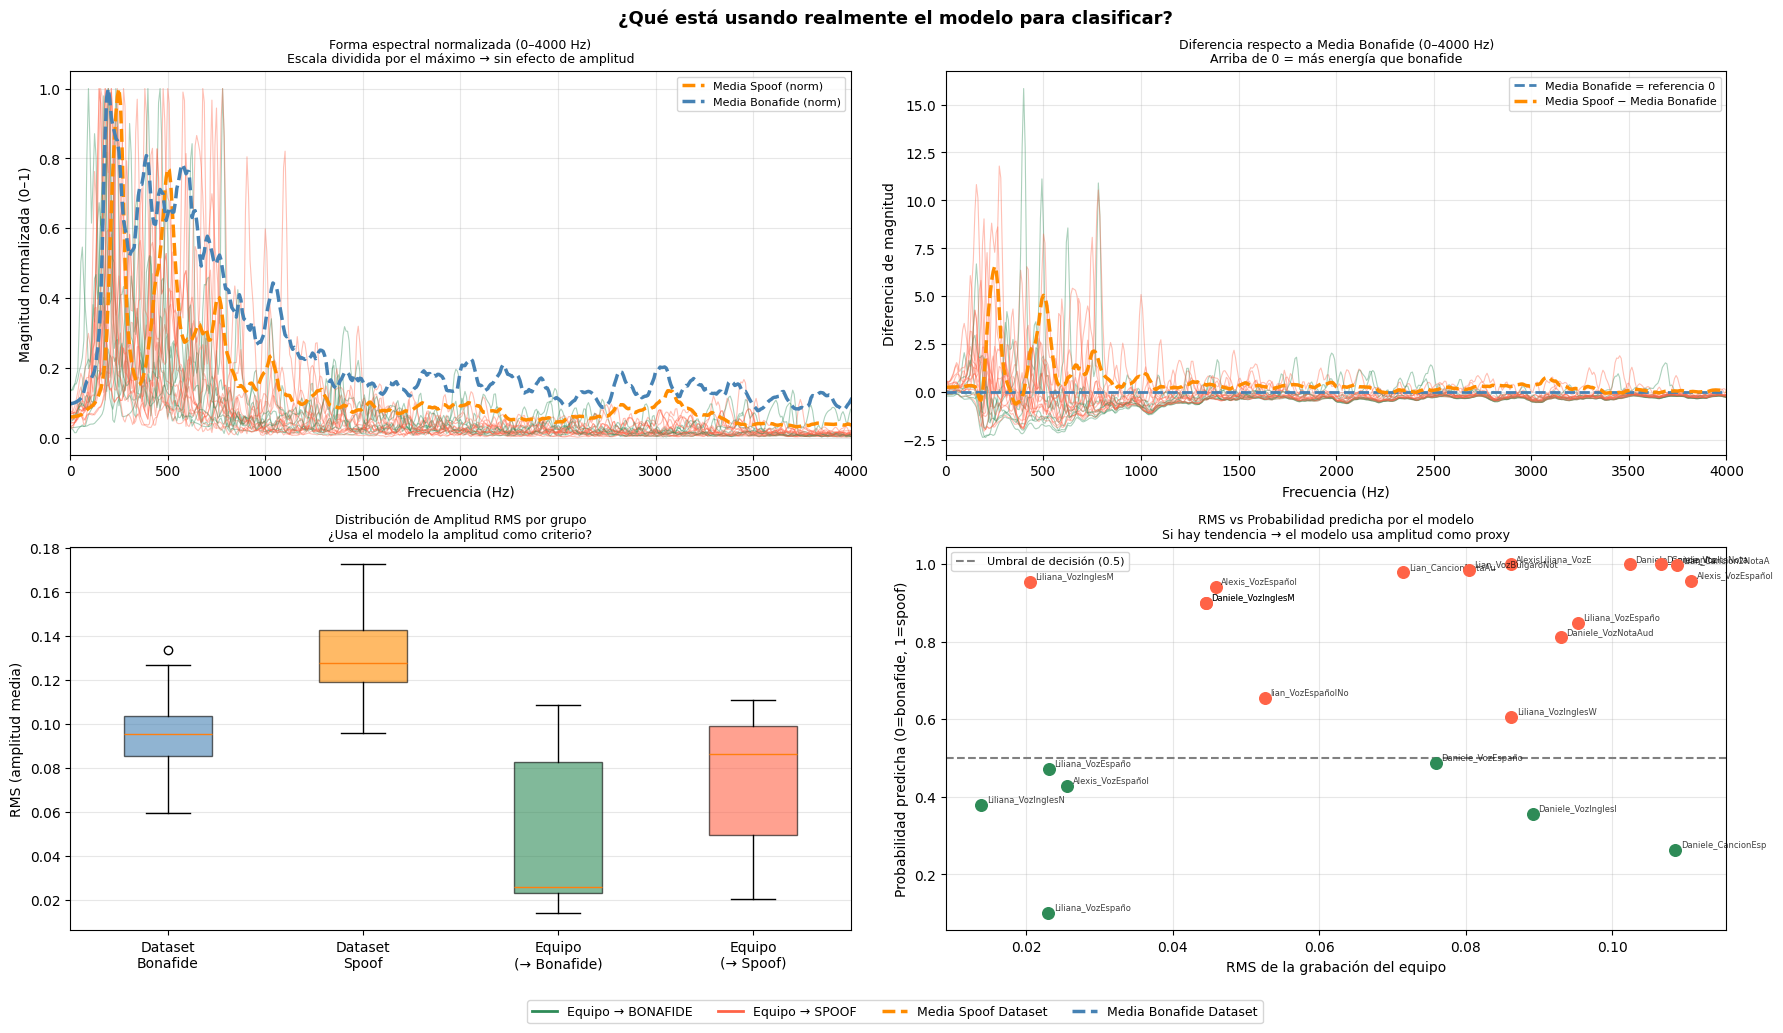

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('¿Qué está usando realmente el modelo para clasificar?',
             fontsize=13, fontweight='bold')

HZ_POR_BIN = 16000 / 2048
hz = np.arange(1025) * HZ_POR_BIN

perfil_media_spoof = media_spoof.mean(axis=0)
perfil_media_bon   = media_bon.mean(axis=0)

# ── Panel 1: Perfiles normalizados (forma sin amplitud) ───────────────────────
ax1 = axes[0, 0]
perfil_spoof_norm = perfil_media_spoof / perfil_media_spoof.max()
perfil_bon_norm   = perfil_media_bon   / perfil_media_bon.max()

for _, row in df.iterrows():
    perfil      = row['spec'].mean(axis=0)
    perfil_norm = perfil / perfil.max()
    color = 'tomato' if row['clase'] == 'spoof' else 'seagreen'
    ax1.plot(hz, perfil_norm, color=color, alpha=0.4, linewidth=0.8)

ax1.plot(hz, perfil_spoof_norm, color='darkorange', linewidth=2.5, linestyle='--', label='Media Spoof (norm)')
ax1.plot(hz, perfil_bon_norm,   color='steelblue',  linewidth=2.5, linestyle='--', label='Media Bonafide (norm)')
ax1.set_xlim(0, 4000)
ax1.set_title('Forma espectral normalizada (0–4000 Hz)\nEscala dividida por el máximo → sin efecto de amplitud', fontsize=9)
ax1.set_xlabel('Frecuencia (Hz)')
ax1.set_ylabel('Magnitud normalizada (0–1)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# ── Panel 2: Diferencia respecto a la media bonafide ─────────────────────────
ax2 = axes[0, 1]
for _, row in df.iterrows():
    perfil     = row['spec'].mean(axis=0)
    diferencia = perfil - perfil_media_bon
    color = 'tomato' if row['clase'] == 'spoof' else 'seagreen'
    ax2.plot(hz, diferencia, color=color, alpha=0.4, linewidth=0.8)

ax2.axhline(0, color='steelblue', linewidth=2, linestyle='--', label='Media Bonafide = referencia 0')
ax2.plot(hz, perfil_media_spoof - perfil_media_bon,
         color='darkorange', linewidth=2.5, linestyle='--', label='Media Spoof − Media Bonafide')
ax2.set_xlim(0, 4000)
ax2.set_title('Diferencia respecto a Media Bonafide (0–4000 Hz)\nArriba de 0 = más energía que bonafide', fontsize=9)
ax2.set_xlabel('Frecuencia (Hz)')
ax2.set_ylabel('Diferencia de magnitud')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# ── Panel 3: Box plot RMS por grupo ───────────────────────────────────────────
ax3 = axes[1, 0]

rms_bon_eq  = [np.sqrt(np.mean(r['audio']**2)) for _, r in clasificados_bonafide.iterrows()]
rms_spo_eq  = [np.sqrt(np.mean(r['audio']**2)) for _, r in clasificados_spoof.iterrows()]

rms_bon_ds, rms_spo_ds = [], []
for fname in archivos_bon[:50]:
    try:
        a, _ = librosa.load(os.path.join(RUTA_AUDIO, f"{fname}.flac"), sr=TARGET_SR, mono=True)
        rms_bon_ds.append(np.sqrt(np.mean(a**2)))
    except: pass
for fname in archivos_spoof[:50]:
    try:
        a, _ = librosa.load(os.path.join(RUTA_AUDIO, f"{fname}.flac"), sr=TARGET_SR, mono=True)
        rms_spo_ds.append(np.sqrt(np.mean(a**2)))
    except: pass

data_box   = [rms_bon_ds, rms_spo_ds, rms_bon_eq, rms_spo_eq]
labels_box = ['Dataset\nBonafide', 'Dataset\nSpoof', 'Equipo\n(→ Bonafide)', 'Equipo\n(→ Spoof)']
colors_box = ['steelblue', 'darkorange', 'seagreen', 'tomato']

bp = ax3.boxplot(data_box, labels=labels_box, patch_artist=True)
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax3.set_title('Distribución de Amplitud RMS por grupo\n¿Usa el modelo la amplitud como criterio?', fontsize=9)
ax3.set_ylabel('RMS (amplitud media)')
ax3.grid(True, alpha=0.3, axis='y')

# ── Panel 4: Scatter RMS vs probabilidad predicha ─────────────────────────────
ax4 = axes[1, 1]
for _, row in df.iterrows():
    rms   = np.sqrt(np.mean(row['audio']**2))
    color = 'tomato' if row['clase'] == 'spoof' else 'seagreen'
    ax4.scatter(rms, row['prob'], color=color, s=70, zorder=3)
    ax4.annotate(row['nombre'][:18], (rms, row['prob']),
                 fontsize=6, alpha=0.75, xytext=(4, 2), textcoords='offset points')

ax4.axhline(0.5, color='gray', linestyle='--', linewidth=1.5, label='Umbral de decisión (0.5)')
ax4.set_title('RMS vs Probabilidad predicha por el modelo\nSi hay tendencia → el modelo usa amplitud como proxy', fontsize=9)
ax4.set_xlabel('RMS de la grabación del equipo')
ax4.set_ylabel('Probabilidad predicha (0=bonafide, 1=spoof)')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

from matplotlib.lines import Line2D
fig.legend(handles=[
    Line2D([0],[0], color='seagreen',   linewidth=2, label='Equipo → BONAFIDE'),
    Line2D([0],[0], color='tomato',     linewidth=2, label='Equipo → SPOOF'),
    Line2D([0],[0], color='darkorange', linewidth=2.5, linestyle='--', label='Media Spoof Dataset'),
    Line2D([0],[0], color='steelblue',  linewidth=2.5, linestyle='--', label='Media Bonafide Dataset'),
], loc='lower center', ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.show()


### Observaciones de Resultados:

1. Forma espectral normalizada: la distribución de frecuencias del equipo no coincide claramente ni con spoof ni con bonafide del dataset, vemos alta variabilidad entre grabaciones.

2. Diferencia respecto a bonafide: las grabaciones del equipo tienen más energía que la media bonafide en frecuencias bajas (0–500 Hz), lo que indica que el canal de grabación (celular/pc + AAC) altera esa zona específica.

3. box plot RMS:  observado desde afuera, el dataset spoof tiene amplitud sistemáticamente más alta que el dataset bonafide. Las grabaciones del equipo clasificadas como spoof también tienden a tener mayor RMS que las clasificadas como bonafide, lo que sugiere que existe una correlación entre amplitud y la predicción del modelo, no necesariamente porque el modelo use RMS directamente, sino porque la amplitud refleja las mismas condiciones de grabación que distinguen ambas clases en el dataset de entrenamiento.

4. Scatter RMS vs probabilidad: in embargo, hay grabaciones con RMS muy bajo que igualmente reciben probabilidad de spoof cercana a 1.0, lo que indica que la correlación con amplitud no es suficiente para explicar todas las predicciones. El modelo está respondiendo a patrones que no son capturables con métricas globales de tiempo ni de frecuencia analizadas externamente.

Ninguna visualización logra identificar exactamente qué patrones está detectando el modelo, lo que confirma que el problema es un domain mismatch a nivel de textura espectral fina, demasiado sutil para ser visible en gráficas globales, pero suficiente para que los filtros convolucionales del modelo lo detecten.

## Conclusiones finales

En el dominio del tiempo, nuestras grabaciones se parecen más al bonafide del dataset. Sin embargo, el modelo las clasifica mayoritariamente como spoof porque opera exclusivamente en el dominio de la frecuencia, donde el micrófono del celular y la compresión AAC introducen patrones espectrales que el modelo asocia a síntesis artificial.

| Característica | Bonafide Dataset | Grabación Equipo |
|---|---|---|
| Formato original | FLAC (sin pérdida) | M4A → WAV (AAC) |
| Entorno de grabación | Estudio controlado | Ambiente con reverb |
| Tipo de micrófono | Profesional | Teléfono móvil |

Las condiciones de grabación del equipo introducen en el espectrograma patrones que el modelo asocia al spoof:

- Artefactos del códec AAC (M4A): la compresión introduce distorsiones sutiles en el espectro — bandas artificiales y suavizado de transientes, invisibles en el tiempo pero presentes en el espectrograma. El audio spoof del dataset tiene el mismo tipo de patrones artificiales por ser generado por TTS/vocoders.

- Respuesta en frecuencia del micrófono del móvil: los micrófonos de teléfono amplifican ciertas bandas (típicamente ~1–3 kHz) y cortan otras, creando líneas horizontales en el espectrograma similares a los armónicos artificiales del spoof.

- Reverberación de sala:genera energía sostenida en todos los bins de frecuencia, haciendo el espectrograma más denso que el fondo negro limpio del bonafide del dataset.

Estos patrones son demasiado sutiles para ser visibles en las representaciones globales analizadas, pero suficientes para que los filtros convolucionales del modelo los detecten. El modelo no aprendió a reconocer voz humana per se, sino las características acústicas del entorno de grabación del dataset, una forma de sesgo de dominio (domain mismatch): generaliza bien dentro de los datos vistos, pero falla fuera de ellos.
